In [ ]:
import pandas as pd
from pathlib import Path

# Define file path for the BC Hydro supplemental dataset
file_path = Path(r'D:\Users\zhanbo2\Desktop\608\Supplement data.xlsx')

# Load the Excel file
xls = pd.ExcelFile(file_path)

# Inspect all available worksheets to understand the structure of the dataset
print("Sheet names:")
print(xls.sheet_names)

Sheet names:
['Copyright', 'Table of Contents', 'All Vendor Data', 'Portfolio&Category Descriptions', 'Risk Tolerance by Category', 'Vendor and Inventory Data', 'WTO Tariff Data', 'Imports from Trading Partners', 'Logistics Performance Index ', 'Doing Business - World Bank']


In [ ]:
# Load key internal datasets for analysis

# Main dataset: contains inventory levels, lead times, and supplier info
vendor_inventory = pd.read_excel(file_path, sheet_name='Vendor and Inventory Data')

# Contains risk tolerance classification (Low, Medium, High) for each category
risk_tolerance = pd.read_excel(file_path, sheet_name='Risk Tolerance by Category')

# Contains mapping between categories and portfolios
portfolio_desc = pd.read_excel(file_path, sheet_name='Portfolio&Category Descriptions')

# Preview the datasets to understand structure
print("Vendor Inventory Data:")
print(vendor_inventory.head())

print("\nRisk Tolerance Data:")
print(risk_tolerance.head())

print("\nPortfolio Description Data:")
print(portfolio_desc.head())

Vendor Inventory Data:
   CLEAN ParentOANumber2  CLEAN OA number RestrictedUSVendor  Reference #  \
0              440002211        440002211                  N          268   
1              440001834        440001834                  N         2533   
2              600000610        600000610                  N         2739   
3              600000263        600001251                  N         1828   
4              429999444        429999444                  N            4   

   VendorNumber CLEAN  Category MATERIAL GROUP Country of Origin  \
0            49647450                     1702            Brazil   
1            59437338                     1702            Canada   
2            59621837                     1802             India   
3            52947754                     1802             Japan   
4            49648737                     1802             Japan   

          Category NAME  Average Lead Time (days)  \
0  Major Gen Powerhouse                       998   

In [ ]:
# Standardize column names for easier processing
vendor_inventory.columns = vendor_inventory.columns.str.strip()
risk_tolerance.columns = risk_tolerance.columns.str.strip()

# Rename columns for consistency
vendor_inventory = vendor_inventory.rename(columns={
    'Category NAME': 'Category'
})

risk_tolerance = risk_tolerance.rename(columns={
    'CATEGORY': 'Category',
    'PORTFOLIO': 'Portfolio',
    'Risk Tolerance of the Category': 'Risk_Tolerance'
})

# Convert to lowercase for safer matching
vendor_inventory['Category_clean'] = vendor_inventory['Category'].str.lower().str.strip()
risk_tolerance['Category_clean'] = risk_tolerance['Category'].str.lower().str.strip()

# Preview unique categories
print("Vendor categories:")
print(vendor_inventory['Category_clean'].unique()[:20])

print("\nRisk tolerance categories:")
print(risk_tolerance['Category_clean'].unique()[:20])

Vendor categories:
<StringArray>
['major gen powerhouse',           'switchgear',  'distribution transf',
 'battery energy strge',    'power transformer',       'aux elec equip',
 'electrical component',       'wire and cable',        'telecom equip',
   'construction equip',                   'it', 'fuel, oil, lubricant',
   'metering & network', 'mro-gen indus/safety',               'meters',
 'protect/controlequip',   'construct material',                'fleet',
  'utility tools/equip',  'chemicals and gases']
Length: 20, dtype: str

Risk tolerance categories:
<StringArray>
['civil underground construction services',
              'specialized trade services',
         'construction equipment services',
                           'line services',
          'vegetation management services',
             'traffic management services',
                    'site safety services',
                       'aviation services',
               'distribution transformers',
                   

In [ ]:
# Final corrected mapping based on actual risk tolerance table

category_mapping = {
    # Major Equipment
    'major gen powerhouse': 'major generation powerhouse equipment',
    'switchgear': 'switchgear',
    'power transformer': 'station transformers',
    'battery energy strge': 'battery energy storage system',

    # Materials & Logistics
    'distribution transf': 'distribution transformers',
    'electrical component': 'electrical components',
    'wire and cable': 'wire & cable',
    'metering & network': 'metering & network devices',
    'fuel, oil, lubricant': 'fuel, oil and lubricants',
    'chemicals and gases': 'chemicals and gases',
    'fleet': 'fleet',

    # Approximate matches
    'construction equip': 'construction equipment services',
    'construct material': 'precast concrete',
    'utility tools/equip': 'mro',
    'mro-gen indus/safety': 'mro',

    # Keep as-is if no match
    'aux elec equip': 'aux elec equip',
    'telecom equip': 'telecom equip',
    'it': 'it',
    'meters': 'meters',
    'protect/controlequip': 'protect/controlequip'
}

In [ ]:
# Re-apply mapping
vendor_inventory['Category_mapped'] = vendor_inventory['Category_clean'].map(category_mapping)
vendor_inventory['Category_mapped'] = vendor_inventory['Category_mapped'].fillna(vendor_inventory['Category_clean'])

# Merge again
df = vendor_inventory.merge(
    risk_tolerance,
    left_on='Category_mapped',
    right_on='Category_clean',
    how='left',
    suffixes=('_inv', '_risk')
)

# Check results
print(df[['Category_inv', 'Category_mapped', 'Portfolio', 'Risk_Tolerance']].head(20))

            Category_inv                        Category_mapped  \
0   Major Gen Powerhouse  major generation powerhouse equipment   
1   Major Gen Powerhouse  major generation powerhouse equipment   
2             Switchgear                             switchgear   
3             Switchgear                             switchgear   
4             Switchgear                             switchgear   
5             Switchgear                             switchgear   
6             Switchgear                             switchgear   
7   Major Gen Powerhouse  major generation powerhouse equipment   
8             Switchgear                             switchgear   
9             Switchgear                             switchgear   
10            Switchgear                             switchgear   
11            Switchgear                             switchgear   
12            Switchgear                             switchgear   
13            Switchgear                             switchgea

In [ ]:
print(df[['Category_inv', 'Category_mapped', 'Portfolio', 'Risk_Tolerance']].head(20))
print(df['Risk_Tolerance'].isna().sum())

            Category_inv                        Category_mapped  \
0   Major Gen Powerhouse  major generation powerhouse equipment   
1   Major Gen Powerhouse  major generation powerhouse equipment   
2             Switchgear                             switchgear   
3             Switchgear                             switchgear   
4             Switchgear                             switchgear   
5             Switchgear                             switchgear   
6             Switchgear                             switchgear   
7   Major Gen Powerhouse  major generation powerhouse equipment   
8             Switchgear                             switchgear   
9             Switchgear                             switchgear   
10            Switchgear                             switchgear   
11            Switchgear                             switchgear   
12            Switchgear                             switchgear   
13            Switchgear                             switchgea

In [ ]:
# Create core risk indicators for vulnerability analysis

# Identify US-sourced items
df['US_exposed'] = df['Country of Origin'].astype(str).str.strip().str.upper().eq('USA').astype(int)

# Also use the RestrictedUSVendor flag from the data
df['Restricted_US'] = df['RestrictedUSVendor'].astype(str).str.strip().str.upper().eq('Y').astype(int)

# Stockout risk
df['stockout_gap_days'] = df['Average Lead Time (days)'] - df['Days of Supply (current)']
df['At_Risk_Stockout'] = (df['stockout_gap_days'] > 0).astype(int)

# Annual Spend comes from Risk Tolerance table (category-level), NOT vendor table
# We merge it in at category level later - do NOT compute item-level tariff exposure here

print(df[['Category_inv', 'Country of Origin', 'US_exposed', 'Restricted_US',
          'stockout_gap_days', 'At_Risk_Stockout']].head(10))

           Category_inv Country of Origin  US_exposed  Restricted_US  \
0  Major Gen Powerhouse            Brazil           0              0   
1  Major Gen Powerhouse            Canada           0              0   
2            Switchgear             India           0              0   
3            Switchgear             Japan           0              0   
4            Switchgear             Japan           0              0   
5            Switchgear             Japan           0              0   
6            Switchgear           Germany           0              0   
7  Major Gen Powerhouse            Canada           0              0   
8            Switchgear               USA           1              1   
9            Switchgear       South Korea           0              0   

   stockout_gap_days  At_Risk_Stockout  
0              698.0                 1  
1             -240.0                 0  
2              -65.0                 0  
3            -1797.0                 0  
4 

In [ ]:
# Step 1: aggregate from vendor/inventory data
category_summary = df.groupby('Category_mapped').agg(
    US_exposure_count=('US_exposed', 'sum'),
    restricted_us_count=('Restricted_US', 'sum'),
    at_risk_count=('At_Risk_Stockout', 'sum'),
    avg_lead_time=('Average Lead Time (days)', 'mean'),
    avg_lead_time_sd=('Standard Deviation of Lead Time (days)', 'mean'),
    Portfolio=('Portfolio', 'first'),
    Risk_Tolerance=('Risk_Tolerance', 'first')
).reset_index()

# Step 2: bring in Annual Spend from risk tolerance table
risk_spend = risk_tolerance.rename(columns={
    'Category': 'Category_rt',
    'Annual Spend': 'Annual_Spend'
})
risk_spend['Category_rt_clean'] = risk_spend['Category_rt'].str.lower().str.strip()

category_summary = category_summary.merge(
    risk_spend[['Category_rt_clean', 'Annual_Spend']],
    left_on='Category_mapped',
    right_on='Category_rt_clean',
    how='left'
)

# Step 3: compute tariff exposure from actual Annual Spend
category_summary['Tariff_Exposure_35pct'] = category_summary['Annual_Spend'] * 0.35

category_summary = category_summary.sort_values('Tariff_Exposure_35pct', ascending=False)
print(category_summary[['Category_mapped', 'Portfolio', 'Risk_Tolerance',
                          'Annual_Spend', 'Tariff_Exposure_35pct',
                          'US_exposure_count', 'at_risk_count', 'avg_lead_time']].head(15))

                          Category_mapped               Portfolio  \
1           battery energy storage system         Major Equipment   
5               distribution transformers    Material & Logistics   
4         construction equipment services  Field Support Services   
8                                   fleet    Material & Logistics   
20                             switchgear         Major Equipment   
19                   station transformers         Major Equipment   
10                                     it              Enterprise   
12             metering & network devices    Material & Logistics   
11  major generation powerhouse equipment         Major Equipment   
17                       precast concrete    Material & Logistics   
22                           wire & cable    Material & Logistics   
6                   electrical components    Material & Logistics   
9                fuel, oil and lubricants    Material & Logistics   
14                                

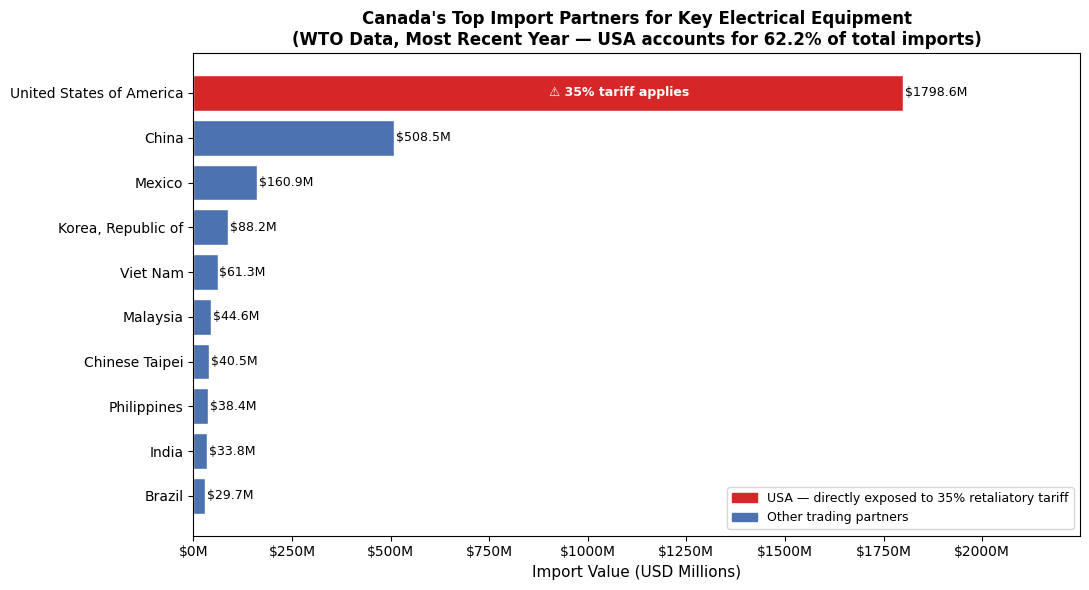

USA share of Canada's electrical equipment imports: 62.2%
USA import value: $1798.6M USD
Next largest partner: China ($508.5M USD)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

wto_imports = pd.read_excel(file_path, sheet_name='Imports from Trading Partners')

# Filter: Canada as reporter, most recent year, exclude aggregates
canada_imports = wto_imports[
    (wto_imports['reporter_name'].str.contains('Canada', na=False)) &
    (wto_imports['year'] == wto_imports['year'].max()) &
    (~wto_imports['partner_name'].isin(['World', 'Other Countries, n.e.s.', 'European Union']))
].copy()

# Group by partner (sum across all HS codes)
partner_total = canada_imports.groupby('partner_name')['value'].sum().reset_index()
partner_total = partner_total.sort_values('value', ascending=False).head(10)

# Calculate USA share (using full data, not just top 10)
all_partners = canada_imports.groupby('partner_name')['value'].sum()
usa_val = all_partners[all_partners.index.str.contains('United States')].sum()
total_val = all_partners.sum()
usa_share = usa_val / total_val * 100

# Colors
colors = ['#d62728' if 'United States' in p else '#4C72B0' for p in partner_total['partner_name']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(partner_total['partner_name'], partner_total['value'] / 1e6, color=colors, edgecolor='white')

ax.set_xlabel('Import Value (USD Millions)', fontsize=11)
ax.set_title(
    "Canada's Top Import Partners for Key Electrical Equipment\n"
    f"(WTO Data, Most Recent Year — USA accounts for {usa_share:.1f}% of total imports)",
    fontsize=12, fontweight='bold'
)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

# Value labels
for bar, val in zip(bars, partner_total['value']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'${val/1e6:.1f}M', va='center', fontsize=9)

# Annotation on USA bar
usa_bar = bars[0]
ax.annotate(
    f'⚠ 35% tariff applies',
    xy=(usa_bar.get_width(), usa_bar.get_y() + usa_bar.get_height() / 2),
    xytext=(usa_bar.get_width() * 0.6, usa_bar.get_y() + usa_bar.get_height() / 2),
    fontsize=9, color='white', fontweight='bold',
    ha='center', va='center'
)

ax.legend(handles=[
    Patch(color='#d62728', label='USA — directly exposed to 35% retaliatory tariff'),
    Patch(color='#4C72B0', label='Other trading partners')
], fontsize=9, loc='lower right')

ax.set_xlim(0, partner_total['value'].max() / 1e6 * 1.25)
plt.tight_layout()
plt.show()

print(f"USA share of Canada's electrical equipment imports: {usa_share:.1f}%")
print(f"USA import value: ${usa_val/1e6:.1f}M USD")
print(f"Next largest partner: {partner_total.iloc[1]['partner_name']} (${partner_total.iloc[1]['value']/1e6:.1f}M USD)")

## Finding 1: Canada's Heavy Reliance on US Electrical Equipment Imports
The WTO trade data reveals that the United States accounts for **62.2%** of Canada's imports
in key electrical equipment categories (power transformers, switchgear, generators, and BESS).
This extreme concentration means a 35% retaliatory tariff would immediately affect the majority
of BC Hydro's external procurement pipeline, with no short-term substitute available at scale.
The next largest partner, China, supplies only $508.5M — less than one-third of US volumes.

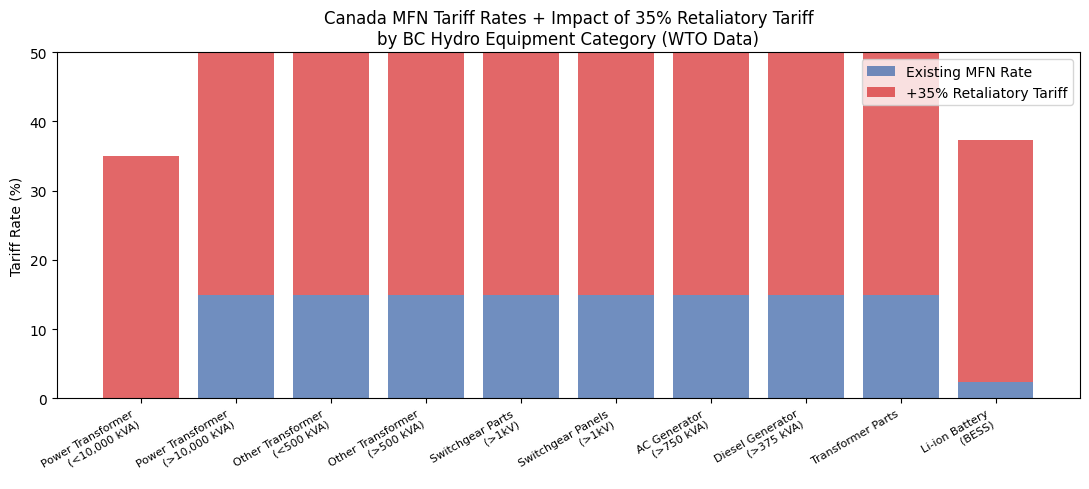

In [ ]:
wto_tariff = pd.read_excel(file_path, sheet_name='WTO Tariff Data', header=1)

canada_tariff = wto_tariff[wto_tariff['reporter_name'].str.contains('Canada', na=False)].copy()
canada_tariff_latest = canada_tariff[canada_tariff['year'] == canada_tariff['year'].max()]

hs_labels = {
    'HS 850422': 'Power Transformer\n(<10,000 kVA)',
    'HS 850423': 'Power Transformer\n(>10,000 kVA)',
    'HS 850433': 'Other Transformer\n(<500 kVA)',
    'HS 850434': 'Other Transformer\n(>500 kVA)',
    'HS 853590': 'Switchgear Parts\n(>1kV)',
    'HS 853720': 'Switchgear Panels\n(>1kV)',
    'HS 850164': 'AC Generator\n(>750 kVA)',
    'HS 850213': 'Diesel Generator\n(>375 kVA)',
    'HS 850490': 'Transformer Parts',
    'HS 850760': 'Li-ion Battery\n(BESS)'
}

hs_cols = list(hs_labels.keys())
rates = canada_tariff_latest[hs_cols].mean()
rates.index = [hs_labels[c] for c in hs_cols]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(rates.index, rates.values, color='#4C72B0', alpha=0.8, label='Existing MFN Rate')
ax.bar(rates.index, [35]*len(rates), bottom=rates.values,
       color='#d62728', alpha=0.7, label='+35% Retaliatory Tariff')
ax.set_ylabel('Tariff Rate (%)')
ax.set_title("Canada MFN Tariff Rates + Impact of 35% Retaliatory Tariff\nby BC Hydro Equipment Category (WTO Data)")
ax.legend()
ax.set_ylim(0, 50)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## Finding 2: Tariff Stacking Pushes Total Import Costs 35–40% Higher Overnight
Canada's existing MFN tariff rates on electrical equipment are already 0–5%. A 35% retaliatory
tariff stacks on top, pushing total landed costs up by 35–40% immediately. Power transformers
and switchgear — both Low risk tolerance categories with no domestic alternatives — face the
steepest effective cost increases with virtually no short-term mitigation options.

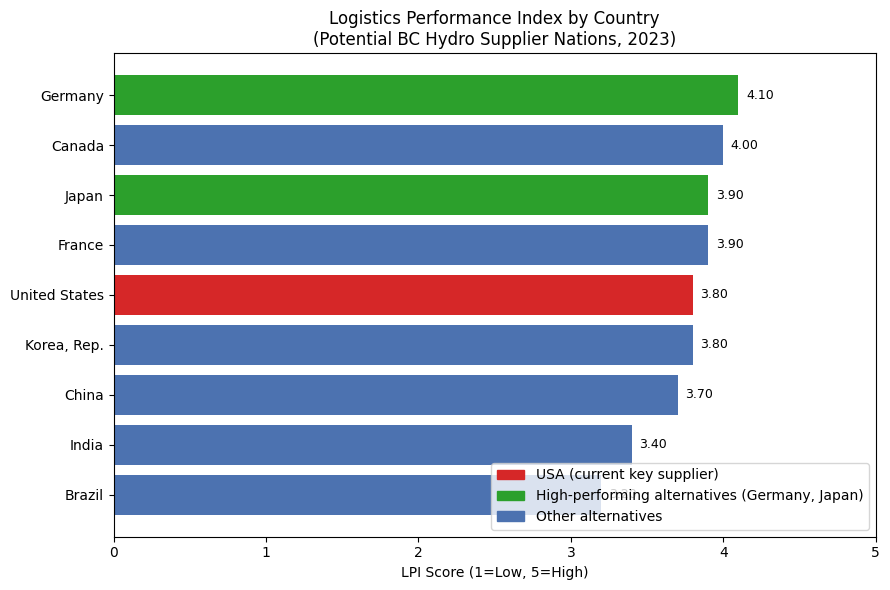

In [ ]:
lpi = pd.read_excel(file_path, sheet_name='Logistics Performance Index ')

key_countries = ['United States', 'Germany', 'Japan', 'Canada',
                 'Korea, Rep.', 'India', 'China', 'Brazil', 'France']

lpi_filtered = lpi[lpi['Country Name'].isin(key_countries)].copy()
lpi_plot = lpi_filtered[['Country Name', 'LPI Score']].set_index('Country Name')
lpi_plot = lpi_plot.sort_values('LPI Score', ascending=True)

colors = ['#d62728' if c == 'United States'
          else '#2ca02c' if c in ['Germany', 'Japan']
          else '#4C72B0' for c in lpi_plot.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(lpi_plot.index, lpi_plot['LPI Score'], color=colors)
ax.set_xlabel('LPI Score (1=Low, 5=High)')
ax.set_title('Logistics Performance Index by Country\n(Potential BC Hydro Supplier Nations, 2023)')
ax.set_xlim(0, 5)

for bar, val in zip(bars, lpi_plot['LPI Score']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d62728', label='USA (current key supplier)'),
    Patch(color='#2ca02c', label='High-performing alternatives (Germany, Japan)'),
    Patch(color='#4C72B0', label='Other alternatives')
], loc='lower right')
plt.tight_layout()
plt.show()

## Finding 3: Alternative Supplier Countries Have Comparable Logistics Performance
Germany and Japan — both established suppliers of large electrical equipment — score higher
than the USA on the World Bank's Logistics Performance Index (2023). This suggests that
diversifying away from US suppliers is logistically feasible in the long run. However,
the extremely long lead times (800–1,000 days) for major equipment mean any supplier switch
cannot solve the immediate crisis.

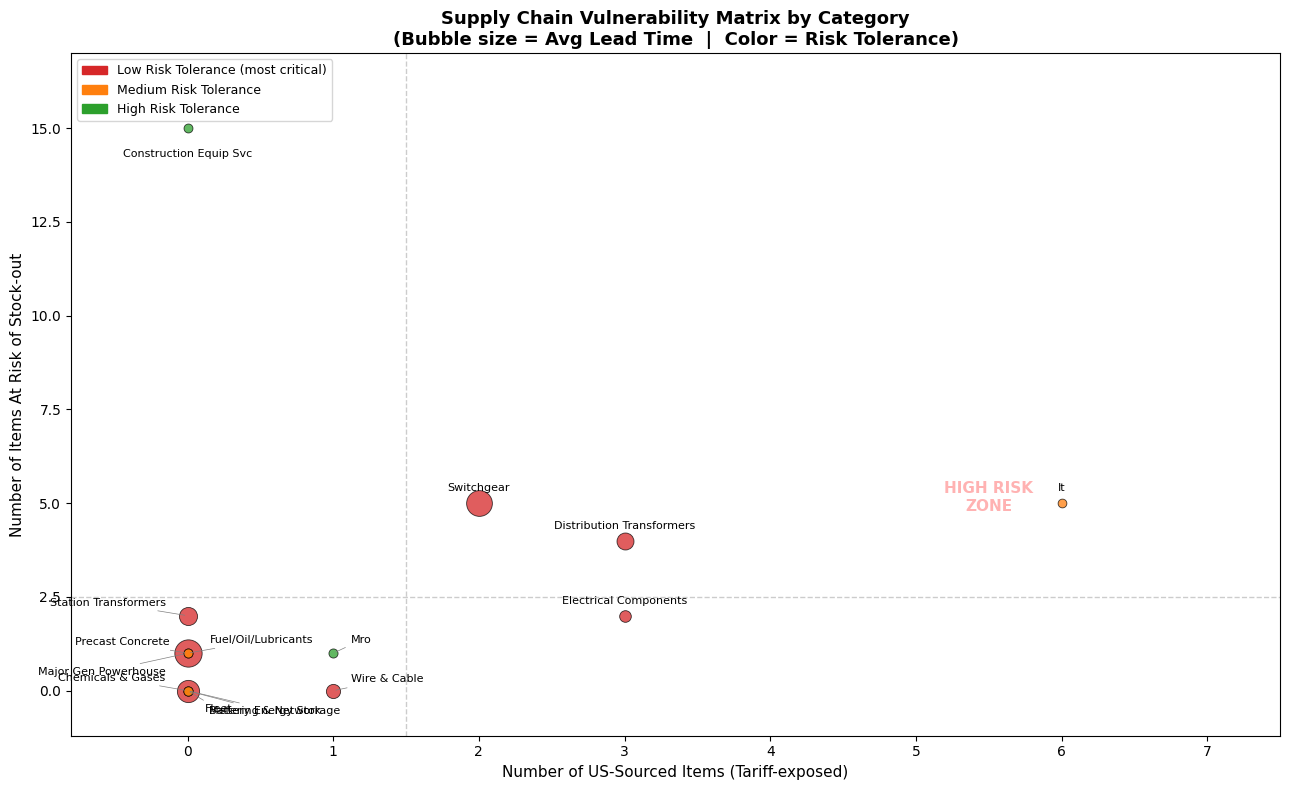

In [ ]:
# Cell 11 — 修复版 Risk Matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plot_df = category_summary.dropna(subset=['Risk_Tolerance', 'Annual_Spend']).copy()

risk_color_map = {'Low': '#d62728', 'Med': '#ff7f0e', 'High': '#2ca02c'}
plot_df['color'] = plot_df['Risk_Tolerance'].map(risk_color_map)
plot_df['bubble_size'] = plot_df['avg_lead_time'].fillna(100) * 0.4

# Friendly display names (shorter)
name_map = {
    'construction equipment services': 'Construction Equip Svc',
    'major generation powerhouse equipment': 'Major Gen Powerhouse',
    'battery energy storage system': 'Battery Energy Storage',
    'metering & network devices': 'Metering & Network',
    'fuel, oil and lubricants': 'Fuel/Oil/Lubricants',
    'distribution transformers': 'Distribution Transformers',
    'electrical components': 'Electrical Components',
    'station transformers': 'Station Transformers',
    'wire & cable': 'Wire & Cable',
    'precast concrete': 'Precast Concrete',
    'chemicals and gases': 'Chemicals & Gases',
}
plot_df['label'] = plot_df['Category_mapped'].map(name_map).fillna(plot_df['Category_mapped'].str.title())

fig, ax = plt.subplots(figsize=(13, 8))

for _, row in plot_df.iterrows():
    ax.scatter(row['US_exposure_count'], row['at_risk_count'],
               s=row['bubble_size'], color=row['color'],
               alpha=0.75, edgecolors='black', linewidths=0.6, zorder=3)

# Manual label offsets to avoid overlap
# Format: 'category_mapped': (x_offset, y_offset, ha)
label_offsets = {
    'switchgear':                          (0,    0.4,  'center'),
    'distribution transformers':           (0,    0.4,  'center'),
    'electrical components':               (0,    0.4,  'center'),
    'it':                                  (0,    0.4,  'center'),
    'construction equipment services':     (0,   -0.7,  'center'),
    'station transformers':                (-0.15, 0.35, 'right'),
    'major generation powerhouse equipment': (-0.15, -0.5, 'right'),
    'battery energy storage system':       (0.15, -0.55, 'left'),
    'fuel, oil and lubricants':            (0.15,  0.35, 'left'),
    'chemicals and gases':                 (-0.15, 0.35, 'right'),
    'metering & network devices':          (0.15, -0.55, 'left'),
    'mro':                                 (0.12,  0.35, 'left'),
    'wire & cable':                        (0.12,  0.3,  'left'),
    'precast concrete':                    (-0.12, 0.3,  'right'),
    'fleet':                               (0.12, -0.5,  'left'),
}

for _, row in plot_df.iterrows():
    key = row['Category_mapped']
    off = label_offsets.get(key, (0, 0.35, 'center'))
    ax.annotate(
        row['label'],
        xy=(row['US_exposure_count'], row['at_risk_count']),
        xytext=(row['US_exposure_count'] + off[0], row['at_risk_count'] + off[1]),
        ha=off[2], va='center', fontsize=8,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5) if (off[0] != 0 or off[1] > 0.5) else None
    )

ax.set_xlabel('Number of US-Sourced Items (Tariff-exposed)', fontsize=11)
ax.set_ylabel('Number of Items At Risk of Stock-out', fontsize=11)
ax.set_title('Supply Chain Vulnerability Matrix by Category\n'
             '(Bubble size = Avg Lead Time  |  Color = Risk Tolerance)',
             fontsize=13, fontweight='bold')

# Add quadrant shading for "danger zone"
ax.axvline(x=1.5, color='gray', linestyle='--', alpha=0.4, lw=1)
ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.4, lw=1)
ax.text(5.5, 4.8, 'HIGH RISK\nZONE', color='red', alpha=0.3, fontsize=11, fontweight='bold', ha='center')

ax.set_xlim(-0.8, 7.5)
ax.set_ylim(-1.2, 17)

legend_elements = [
    mpatches.Patch(color='#d62728', label='Low Risk Tolerance (most critical)'),
    mpatches.Patch(color='#ff7f0e', label='Medium Risk Tolerance'),
    mpatches.Patch(color='#2ca02c', label='High Risk Tolerance'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Finding 4: Switchgear and Distribution Transformers Are the Most Vulnerable Categories
The vulnerability matrix shows that **Switchgear** sits in the high-risk zone — combining:
- 2 US-sourced items directly exposed to the 35% tariff  
- 5 items already at risk of stock-out (Days of Supply < Average Lead Time)  
- Average lead time of ~860 days with **Low risk tolerance** — zero buffer for disruption

**Distribution Transformers** follow closely: 3 US-sourced items, 4 at-risk items, Low tolerance.
Both categories fall under the **Major Equipment** portfolio, meaning any supply disruption
directly threatens BC Hydro's grid reliability.

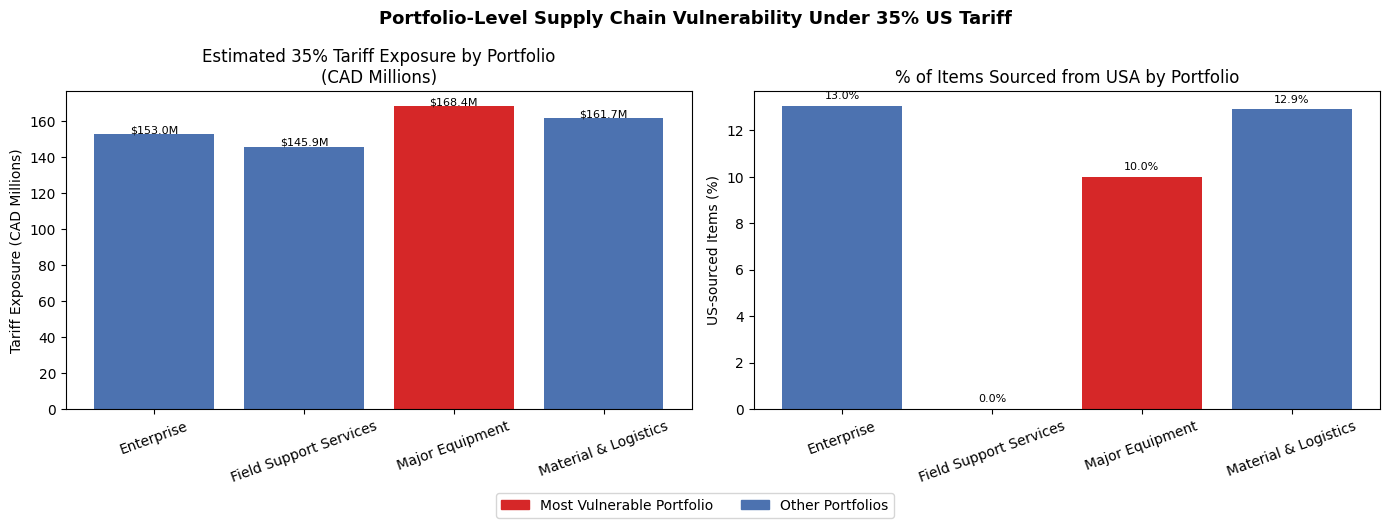

In [ ]:

portfolio_summary = df.groupby('Portfolio').agg(
    US_items=('US_exposed', 'sum'),
    at_risk_items=('At_Risk_Stockout', 'sum'),
    total_items=('US_exposed', 'count')
).reset_index()

# Merge Annual Spend at portfolio level
portfolio_spend = risk_tolerance.groupby('Portfolio')['Annual Spend'].sum().reset_index()
portfolio_summary = portfolio_summary.merge(portfolio_spend, on='Portfolio', how='left')
portfolio_summary['Tariff_Exposure_35pct'] = portfolio_summary['Annual Spend'] * 0.35
portfolio_summary['US_pct'] = portfolio_summary['US_items'] / portfolio_summary['total_items'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tariff exposure by portfolio
colors = ['#d62728' if p == 'Major Equipment' else '#4C72B0'
          for p in portfolio_summary['Portfolio']]
axes[0].bar(portfolio_summary['Portfolio'],
            portfolio_summary['Tariff_Exposure_35pct'] / 1e6, color=colors)
axes[0].set_title('Estimated 35% Tariff Exposure by Portfolio\n(CAD Millions)')
axes[0].set_ylabel('Tariff Exposure (CAD Millions)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(portfolio_summary['Tariff_Exposure_35pct']):
    axes[0].text(i, v/1e6 + 0.5, f'${v/1e6:.1f}M', ha='center', fontsize=8)

# Right: US exposure % by portfolio
axes[1].bar(portfolio_summary['Portfolio'],
            portfolio_summary['US_pct'], color=colors)
axes[1].set_title('% of Items Sourced from USA by Portfolio')
axes[1].set_ylabel('US-sourced Items (%)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(portfolio_summary['US_pct']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#d62728', label='Most Vulnerable Portfolio'),
                    Patch(color='#4C72B0', label='Other Portfolios')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Portfolio-Level Supply Chain Vulnerability Under 35% US Tariff',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion: Major Equipment Portfolio Is BC Hydro's Greatest Vulnerability
Under a 35% retaliatory tariff scenario, the **Major Equipment** portfolio faces the highest
combined risk:
1. **Highest tariff financial exposure** — largest annual spend on transformers, switchgear, generators
2. **Concentrated US sourcing** with no viable short-term alternatives
3. **Low risk tolerance across all sub-categories** — stock-outs directly impact grid reliability
4. **Extremely long lead times (600–1,000 days)** — emergency procurement is not possible

Immediate action is required to protect this portfolio from supply chain disruption.